<a href="https://colab.research.google.com/github/Gen54cw/Analitica-de-Datos-Tintaya-Daniel/blob/main/laboratorios/LAB01_TintayaDaniel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1: Evaluación de factibilidad de un caso de uso analítico

Alumno: Tintaya Avila Daniel Eduardo

Codigo: 21200032

Fecha: 26/08/2026

LINK DE GITHUB: https://github.com/Gen54cw/Analitica-de-Datos-Tintaya-Daniel.git

# Paso 1. Configuración del entorno

In [6]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
print("pandas:", pd.__version__)
print("numpy :", np.__version__)


pandas: 2.2.3
numpy : 2.1.3


Las versiones utilizadas en el notebook corresponden a:

pandas: 2.2.3

numpy: 2.1.3

# Paso 2 · Carga e inventario inicial

In [7]:
#Para subir los csv
#from google.colab import files
#subidos = files.upload() # seleccione los dos archivos CSV
#print(list(subidos.keys()))

In [8]:
citas = pd.read_csv("citas_red_salud.csv", encoding="utf-8")
sedes = pd.read_csv("catalogo_sedes.csv", encoding="utf-8")
print("citas :", citas.shape)
print("sedes :", sedes.shape)
print()
citas.info()
display(citas.head(5))
display(sedes)

citas : (12200, 20)
sedes : (14, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12200 entries, 0 to 12199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cita                 12200 non-null  object 
 1   id_paciente             12200 non-null  object 
 2   sede                    12200 non-null  object 
 3   distrito                11467 non-null  object 
 4   especialidad            12055 non-null  object 
 5   fecha_programacion      12200 non-null  object 
 6   fecha_cita              12200 non-null  object 
 7   hora_cita               12200 non-null  object 
 8   canal_agendamiento      11652 non-null  object 
 9   dias_anticipacion       11933 non-null  float64
 10  edad_paciente           11854 non-null  float64
 11  citas_previas           12200 non-null  int64  
 12  inasistencias_previas   12200 non-null  int64  
 13  telefono_confirmado     4586 non-null   object 
 14  d

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,id_cita,id_paciente,sede,distrito,especialidad,fecha_programacion,fecha_cita,hora_cita,canal_agendamiento,dias_anticipacion,edad_paciente,citas_previas,inasistencias_previas,telefono_confirmado,diagnostico_cie10,estado_cita,fecha_cancelacion,hora_registro_atencion,duracion_atencion_min,motivo_no_asistencia
0,C2407125,P146731,CAP San Martín de Porres,San Martín de Porres,Cardiología,2025-06-11,2025-07-15,09:15,App,34.0,24.0,7,2,NaN,L20.9,Cancelada,2025-06-26,NaN,NaN,NaN
1,C2400808,P122053,CAP Surquillo,Surquillo,Ginecología,2025-08-20,01/09/2025,08:00,Telefonico,12.0,66.0,2,2,Si,E78.5,Atendida,NaN,08:00,6.0,NaN
2,C2401689,P142968,CAP Independencia,Independencia,Dermatología,2026-01-07,2026-01-14,10:45,Presencial,7.0,33.0,4,1,No,G43.9,Cancelada,2026-01-08,NaN,NaN,NaN
3,C2410000,P101367,CAP Santa Anita,Santa Anita,Endocrinología,2025-10-30,2025-12-01,11:30,app movil,32.0,4.0,9,2,NaN,J45,Atendida,NaN,11:13,14.0,NaN
4,C2401784,P116873,CAP Puente Piedra,Puente Piedra,Odontología,2024-11-02,2024-11-14,16:15,Web,12.0,50.0,5,1,NaN,E11.9,Atendida,NaN,16:40,10.0,NaN


,sede,distrito,nivel_establecimiento,consultorios_ambulatorios,anio_apertura,horas_medico_semana
0,CAP San Juan de Lurigancho,San Juan de Lurigancho,I-4,22,2009,980
1,CAP Comas,Comas,I-4,18,2011,810
2,CAP Villa El Salvador,Villa El Salvador,I-3,14,2014,640
3,CAP Ate,Ate,I-4,19,2010,850
4,CAP San Martin de Porres,San Martín de Porres,I-3,15,2013,690
5,CAP Callao,Callao,II-1,26,2006,1180
6,CAP Los Olivos,Los Olivos,I-4,17,2012,760
7,CAP Chorrillos,Chorrillos,I-3,13,2015,590
8,CAP Santa Anita,Santa Anita,I-3,12,2016,545
9,CAP Puente Piedra,Puente Piedra,I-3,11,2017,500


**Preguntas**

**2.1 ¿Cuántas filas y cuántas columnas tiene cada archivo?**

citas:  12200 filas y 20 columnas

sedes: 14 filas y 6 columnas

2.2 ¿Qué columnas deberían ser numéricas o de fecha pero llegaron como texto? Enumérelas.


*   fecha_programacion
*   fecha_cita
*   hora_cita
*   fecha_cancelacion
*   hora_registro_atencion

Estas columnas no deben ser consideradas como texto


**2.3 A partir de los nombres de las columnas y de las primeras filas, ¿cuál cree que es la granularidad del archivo principal, es decir, qué representa una fila?**

La fila representa una cita programada de un paciente en una sede determinada, además de contener información relacionada con la programación de la cita, el paciente y el estado final de la cita.

# Paso 3 · Diccionario de datos

## Diccionario de datos

| Variable | Significado | Tipo esperado |
|---|---|---|
| `id_cita` | Identificador de la cita programada. Debería ser único. | Texto (clave) |
| `id_paciente` | Identificador del paciente. Se repite entre citas. | Texto (clave foránea) |
| `sede` | Establecimiento donde se programó la atención. | Categórica |
| `distrito` | Distrito del establecimiento. | Categórica |
| `especialidad` | Especialidad médica de la cita. | Categórica |
| `fecha_programacion` | Fecha en que se agendó la cita. | Fecha |
| `fecha_cita` | Fecha para la que se programó la atención. | Fecha |
| `hora_cita` | Hora programada de la atención. | Hora |
| `canal_agendamiento` | Medio por el que se agendó: presencial, teléfono, app o web. | Categórica |
| `dias_anticipacion` | Días entre el agendamiento y la cita, según el sistema. | Entero ≥ 0 |
| `edad_paciente` | Edad del paciente en años. | Entero, 0 a 110 |
| `citas_previas` | Número de citas históricas del paciente en la red. | Entero ≥ 0 |
| `inasistencias_previas` | Número de inasistencias históricas del paciente. | Entero ≥ 0 |
| `telefono_confirmado` | Si el teléfono de contacto fue verificado. | Categórica (Si/No) |
| `diagnostico_cie10` | Código de diagnóstico asociado a la atención. | Categórica |
| `estado_cita` | Estado final: Atendida, No atendida o Cancelada. | Categórica |
| `fecha_cancelacion` | Fecha en que el paciente canceló, si canceló. | Fecha |
| `hora_registro_atencion` | Hora en que se registró el ingreso del paciente al consultorio. | Hora |
| `duracion_atencion_min` | Duración de la consulta en minutos. | Entero |
| `motivo_no_asistencia` | Motivo registrado cuando el paciente no se presentó. | Categórica |

In [9]:
categoricas = ["sede", "distrito", "especialidad", "canal_agendamiento",
 "estado_cita", "telefono_confirmado"]
for col in categoricas:
 print("=" * 60)
 print(col, "->", citas[col].nunique(dropna=True), "valores distintos")
 print(citas[col].value_counts(dropna=False).head(12))

sede -> 30 valores distintos
sede
CAP Ate                       877
CAP Santa Anita               871
CAP San Martín de Porres      853
CAP Lince                     851
CAP El Agustino               848
CAP Villa El Salvador         838
CAP San Juan de Lurigancho    837
CAP Chorrillos                837
CAP Surquillo                 834
CAP Callao                    829
CAP Los Olivos                824
CAP Puente Piedra             819
Name: count, dtype: int64
distrito -> 14 valores distintos
distrito
Ate                       855
Lince                     839
Santa Anita               835
Villa El Salvador         832
San Martín de Porres      824
San Juan de Lurigancho    822
El Agustino               820
Chorrillos                815
Puente Piedra             813
Surquillo                 810
Callao                    806
Los Olivos                803
Name: count, dtype: int64
especialidad -> 30 valores distintos
especialidad
Odontología         1175
Oftalmología        1119
Neur

**RESPUESTA PASO 3**

**3.1 La red tiene catorce sedes y diez especialidades. ¿Cuántos valores distintos reporta el archivo para esas dos columnas? ¿Cómo se explica la diferencia?**

El archivo reporta 30 valores distintos para sede y 30 valores distintos para especialidad. La diferencia se explica en la forma de registrar las categorías. Por ejemplo, Dermatología y DERMATOLOGÍA aparecen como valores distintos. Por lo tanto, el número de valores distintos observado en el archivo no coincide

**3.2 Identifique al menos tres formas en que un mismo valor aparece escrito de manera distinta.**

Se observan, entre otras, las siguientes variantes:

*   Dermatología / DERMATOLOGÍA
*   Presencial / PRESENCIAL
*   App / app movil

**3.3 ¿Qué columna tiene una proporción de valores faltantes tan alta que probablemente no sea utilizable? Justifique.**

La columna de telefono_confirmado, porque de 12200 registros 7614 esta como NaN lo que indica que no contiene información

# Paso 4 · Normalización de categorías y fechas

In [10]:
def normaliza(texto):
    """Minúsculas, sin tildes, sin espacios sobrantes."""
    if pd.isna(texto):
        return np.nan

    t = str(texto).strip().lower()
    t = unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode("ascii")
    return " ".join(t.split())


for col in ["sede", "distrito", "especialidad", "canal_agendamiento", "estado_cita"]:
    citas[col + "_norm"] = citas[col].apply(normaliza)

print(citas["estado_cita_norm"].value_counts(dropna=False))
print()
print(citas["canal_agendamiento_norm"].value_counts(dropna=False))
print()
print("sedes distintas :", citas["sede_norm"].nunique())
print("especialidades distintas:", citas["especialidad_norm"].nunique())

estado_cita_norm
atendida       7252
no atendida    3652
cancelada      1296
Name: count, dtype: int64

canal_agendamiento_norm
presencial    4024
telefonico    2879
app           2445
web           2070
NaN            548
app movil      234
Name: count, dtype: int64

sedes distintas : 15
especialidades distintas: 10


In [11]:
def parse_fecha(serie):
    iso = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    lat = pd.to_datetime(serie, format="%d/%m/%Y", errors="coerce")
    return iso.fillna(lat)


citas["fecha_cita_dt"] = parse_fecha(citas["fecha_cita"])
citas["fecha_prog_dt"] = parse_fecha(citas["fecha_programacion"])

print("fecha_cita no interpretadas :", citas["fecha_cita_dt"].isna().sum())
print("fecha_programacion no interpretadas :", citas["fecha_prog_dt"].isna().sum())

print(
    "rango de fechas de cita:",
    citas["fecha_cita_dt"].min().date(),
    "a",
    citas["fecha_cita_dt"].max().date()
)

fecha_cita no interpretadas : 0
fecha_programacion no interpretadas : 0
rango de fechas de cita: 2024-01-02 a 2026-06-29


**RESPUESTAS PASO 4**

**4.1 ¿Cuántos valores distintos quedaron en sede y especialidad después de normalizar? ¿Coincide ahora con lo que la red declara?**

Quedaron 15 sedes y 10 especialidades distintas. No, no coincide en las sedes, porque la red declara 14 sedes lo que indica que la normalización no logro capturar todo

**4.2 Después de normalizar, el canal de agendamiento todavía tiene una categoría de más. ¿Cuál es y qué haría usted con ella?**

La categoria que sobra es la de app movil que es la misma que app. Lo trataria como una variante de app, y las unificaria en una columna, incluyendo los registros faltantes

**4.3 ¿Por qué es una mala práctica sobrescribir la columna original en lugar de crear una columna nueva?**

Porque se pierde como fue registrado de forma original y no permitiria trazar y verificar la información.

# Paso 5 · Resolución de duplicados

In [12]:
# a) Duplicados exactos
dup_exactos = citas.duplicated().sum()
print("Filas idénticas en todas sus columnas:", dup_exactos)

# b) Identificadores repetidos con contenido distinto
citas_sin_exactos = citas.drop_duplicates()
mask = citas_sin_exactos["id_cita"].duplicated(keep=False)
print("Filas con id_cita repetido y contenido distinto:", mask.sum())

# Inspeccione un caso concreto antes de decidir
ejemplo = citas_sin_exactos.loc[mask, "id_cita"].iloc[0]
display(citas_sin_exactos[citas_sin_exactos["id_cita"] == ejemplo])


Filas idénticas en todas sus columnas: 127
Filas con id_cita repetido y contenido distinto: 146


,id_cita,id_paciente,sede,distrito,especialidad,fecha_programacion,fecha_cita,hora_cita,canal_agendamiento,dias_anticipacion,edad_paciente,citas_previas,inasistencias_previas,telefono_confirmado,diagnostico_cie10,estado_cita,fecha_cancelacion,hora_registro_atencion,duracion_atencion_min,motivo_no_asistencia,sede_norm,distrito_norm,especialidad_norm,canal_agendamiento_norm,estado_cita_norm,fecha_cita_dt,fecha_prog_dt
165,C2403465,P107703,CAP Ate,Ate,Medicina General,2026-02-04,2026-02-23,09:30,Web,19.0,1.0,5,2,Si,H52.1,No atendida,NaN,NaN,NaN,No registrado,cap ate,ate,medicina general,web,no atendida,2026-02-23,2026-02-04
4013,C2403465,P107703,CAP Ate,Ate,Medicina General,2026-02-04,2026-02-23,18:30,app movil,19.0,1.0,5,2,Si,H52.1,No atendida,NaN,NaN,NaN,No registrado,cap ate,ate,medicina general,app movil,no atendida,2026-02-23,2026-02-04


In [13]:
citas_lim = (citas
    .drop_duplicates() # elimina exactos
    .drop_duplicates(subset="id_cita", keep="first") # conserva primera versión
    .reset_index(drop=True))

print("Filas originales :", len(citas))
print("Filas resultantes:", len(citas_lim))
print("Filas descartadas:", len(citas) - len(citas_lim),
      f"({(len(citas)-len(citas_lim))/len(citas)*100:.2f} %)")


Filas originales : 12200
Filas resultantes: 12000
Filas descartadas: 200 (1.64 %)


**RESPUESTAS PASO 5**

**5.1 ¿Cuántos duplicados exactos y cuántos identificadores repetidos encontró?**

Hay 127 duplicados exactos y 146 filas con id_cita repetido y contenido distinto.

**5.2 Observe el caso concreto que inspeccionó: ¿en qué columnas difieren las dos versiones de la misma cita?**

Difieren en la hora_cita, canal_Agendamiento y canal_agendamiento_norm

**5.3 Conservar la primera aparición es una decisión arbitraria. Proponga un criterio mejor para decidir cuál versión conservar y explique qué información adicional necesitaría para aplicarlo.**

Se conservaria la versión más reciente, es decir la ultima en modificarse, para lo cual se necesitaria la fecha y hora de modificación del dataset

# Paso 6 · Auditoría de la variable objetivo

In [14]:
# Definición operativa de la variable objetivo
citas_lim["inasistencia"] = (citas_lim["estado_cita_norm"] == "no atendida").astype(int)
print(citas_lim["estado_cita_norm"].value_counts(dropna=False))
print()
print("Citas marcadas como inasistencia:", citas_lim["inasistencia"].sum())
# ¿Hay estados nulos o inesperados que no encajen en las tres categorías?
esperados = {"atendida", "no atendida", "cancelada"}
raros = set(citas_lim["estado_cita_norm"].dropna().unique()) - esperados
print("Estados inesperados:", raros if raros else "ninguno")
print("Estados nulos :", citas_lim["estado_cita_norm"].isna().sum())


estado_cita_norm
atendida       7128
no atendida    3592
cancelada      1280
Name: count, dtype: int64

Citas marcadas como inasistencia: 3592
Estados inesperados: ninguno
Estados nulos : 0


In [15]:
coherencia = pd.crosstab(citas_lim["estado_cita_norm"],
                         citas_lim["fecha_cancelacion"].notna(),
                         rownames=["estado"], colnames=["tiene fecha_cancelacion"])
display(coherencia)

tiene fecha_cancelacion,False,True
estado,,
atendida,7098,30
cancelada,0,1280
no atendida,3567,25


**Preguntas a responder en el notebook (Paso 6)**

**6.1 ¿Qué proporción de las citas quedó clasificada en cada uno de los tres estados?**

Atendida: 7 128 (59,40 %)

No atendida: 3 592 (29,93 %)

Cancelada: 1 280 (10,67 %)


**6.2 La tabla de coherencia muestra registros contradictorios. Descríbalos y cuantifíquelos.**

Se encontraron 55 registros contradictorios ya que 30 citas atendidas tienen fecha de cancelación y 25 citas no atendidas tienen fecha de cancelación.

**6.3 A la luz de lo anterior, ¿considera que la variable objetivo está registrada de forma suficientemente confiable como para entrenar un modelo? Responda sí o no y sustente en una o dos frases. Esta respuesta condiciona todo el resto del laboratorio.**

Si, porque a pesar de existir 55 registros contradictorios estos solo representan el 0.46% del total de 12000 registros. Demostrando que más del 99% es constistente y las contradicciones son detectables, lo que puede corregirse


# Paso 7 · Cálculo de la línea base

In [16]:
linea_base = citas_lim["inasistencia"].mean()
print(f"Línea base global de inasistencia sin aviso: {linea_base*100:.2f} %")
print(f"Cifra afirmada por la gerencia : 27.00 %")
print(f"Diferencia : {(linea_base-0.27)*100:+.2f}puntos")

Línea base global de inasistencia sin aviso: 29.93 %
Cifra afirmada por la gerencia : 27.00 %
Diferencia : +2.93puntos


In [17]:
por_sede = (citas_lim.groupby("sede_norm")["inasistencia"].agg(tasa="mean", citas="size").sort_values("tasa", ascending=False))
por_sede["tasa"] = (por_sede["tasa"] * 100).round(2)
display(por_sede)
por_esp = (citas_lim.groupby("especialidad_norm")["inasistencia"].agg(tasa="mean", citas="size").sort_values("tasa", ascending=False))
por_esp["tasa"] = (por_esp["tasa"] * 100).round(2)
display(por_esp)
por_canal = (citas_lim.groupby("canal_agendamiento_norm")["inasistencia"].agg(tasa="mean", citas="size"))
por_canal["tasa"] = (por_canal["tasa"] * 100).round(2)
display(por_canal)


,tasa,citas
sede_norm,,
cap ate,37.07,874
cap el agustino,36.66,851
cap los olivos,36.23,828
cap lince,32.94,853
cap comas,32.85,834
cap villa el salvador,31.87,866
cap surquillo,30.30,845
cap carabayllo,29.67,91
cap san martin de porres,27.22,867


,tasa,citas
especialidad_norm,,
odontologia,37.38,1252
pediatria,35.55,1128
dermatologia,34.49,1186
medicina general,30.42,1167
traumatologia,30.28,1146
ginecologia,29.92,1190
oftalmologia,27.72,1223
cardiologia,26.21,1194
endocrinologia,24.77,1175


,tasa,citas
canal_agendamiento_norm,,
app,34.91,2412
app movil,29.57,230
presencial,24.61,3958
telefonico,28.36,2846
web,36.31,2016


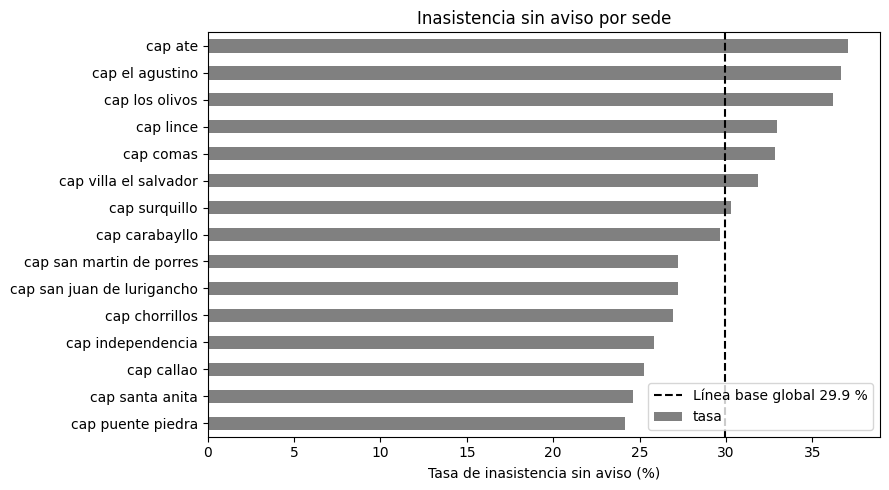

In [18]:
ax = por_sede["tasa"].sort_values().plot(kind="barh", figsize=(9, 5), color="gray")
ax.axvline(linea_base * 100, linestyle="--", color="black",label=f"Línea base global {linea_base*100:.1f} %")
ax.set_xlabel("Tasa de inasistencia sin aviso (%)")
ax.set_ylabel("")
ax.set_title("Inasistencia sin aviso por sede")
ax.legend()
plt.tight_layout(); plt.show()


**Preguntas a responder en el notebook (Paso 7)**

**7.1 ¿Cuál es la línea base real y en cuántos puntos difiere de la cifra que afirma la gerencia?**
Proponga al menos dos explicaciones posibles de esa diferencia.

La línea base real de inasistencia es 29,93 % y a gerencia afirma que es 27%. Ello puede tener como explicación diferente periodo de tiempo, o se excluya algunos casos como citas posteriormente canceladas

**7.2 ¿Cuál es la distancia entre la sede con mayor y la sede con menor tasa? ¿Y entreespecialidades?**

La sede de mayor tasa es cap Ate con 37.07% y cap puente piedra con 24.16%. Dando una distancia de 14.92%.

Entre especialidades es Odontologia (37.38%) y Neurología(22.76%). Con una distancia de 14.62%

**7.3 Suponga que la red decidiera no construir ningún modelo y simplemente llamara siempre a las citas de las tres sedes con peor tasa. ¿Le parece que esa regla simple sería una alternativa razonable al modelo? Argumente a favor y en contra.**

Si, porque permite concentrar las llamadas en las sedes con mayor tasa de inasistencia, además de ser facil de implementar. Sin embargo, ello llevaria a que todas esas citas sean de riesgo.

**7.4 Con la línea base que usted calculó, ¿sigue siendo alcanzable la meta de 21 % planteada en la sesión de teoría? ¿Qué recomendaría?**

Si, todavia es alcanzable, pero aumenta la dificultad. Se intentaria evaluar si un modelo predictivo puede identificar a las citas con mayor riesgo

# Paso 8 · Perfil de calidad de datos

In [19]:
#Completitud
perfil = pd.DataFrame({
    "nulos": citas_lim.isna().sum(),
    "nulos_%": (citas_lim.isna().mean() * 100).round(2),
    "unicos": citas_lim.nunique(dropna=True),
    "tipo": citas_lim.dtypes.astype(str)
}).sort_values("nulos_%", ascending=False)
display(perfil)

,nulos,nulos_%,unicos,tipo
fecha_cancelacion,10665,88.88,721,object
motivo_no_asistencia,8441,70.34,5,object
telefono_confirmado,7504,62.53,2,object
hora_registro_atencion,4894,40.78,648,object
duracion_atencion_min,4894,40.78,36,float64
distrito,720,6.00,14,object
distrito_norm,720,6.00,14,object
canal_agendamiento_norm,538,4.48,5,object
canal_agendamiento,538,4.48,6,object
edad_paciente,335,2.79,102,float64


In [20]:
#8.2 Validez
edad_mala = ((citas_lim["edad_paciente"] < 0) |
 (citas_lim["edad_paciente"] > 110)).sum()
antic_mala = ((citas_lim["dias_anticipacion"] < 0) |
 (citas_lim["dias_anticipacion"] > 365)).sum()
print("Edades fuera de dominio :", edad_mala)
print("Anticipaciones fuera de dominio :", antic_mala)
print()
display(citas_lim.loc[(citas_lim["edad_paciente"] < 0) |
 (citas_lim["edad_paciente"] > 110),["id_cita", "edad_paciente", "dias_anticipacion"]].head(10))

Edades fuera de dominio : 44
Anticipaciones fuera de dominio : 35



,id_cita,edad_paciente,dias_anticipacion
93,C2406150,201.0,17.0
711,C2406489,155.0,5.0
1006,C2403059,-1.0,14.0
1180,C2400968,155.0,17.0
1232,C2407695,132.0,19.0
1511,C2410150,-3.0,9.0
1628,C2401562,155.0,2.0
2123,C2402036,201.0,10.0
2299,C2400373,132.0,NaN
2604,C2401370,-3.0,10.0


In [21]:
#8.3 Consistencia interna
citas_lim["antic_calculada"] = (citas_lim["fecha_cita_dt"] - citas_lim["fecha_prog_dt"]).dt.days
dif = (citas_lim["antic_calculada"] - citas_lim["dias_anticipacion"]).abs()
inconsistentes = (dif > 1).sum()
print("Registros donde dias_anticipacion no coincide con las fechas:", inconsistentes)
print(f"Equivale al {inconsistentes/len(citas_lim)*100:.2f} % del total")
print()
display(citas_lim.loc[dif > 1, ["id_cita", "fecha_prog_dt", "fecha_cita_dt", "dias_anticipacion", "antic_calculada"]].head(8))


Registros donde dias_anticipacion no coincide con las fechas: 241
Equivale al 2.01 % del total



,id_cita,fecha_prog_dt,fecha_cita_dt,dias_anticipacion,antic_calculada
111,C2406416,2025-10-16,2025-11-01,23.0,16
130,C2408203,2024-10-13,2024-10-22,33.0,9
137,C2408078,2024-05-31,2024-06-17,999.0,17
232,C2402378,2025-09-02,2025-09-22,28.0,20
291,C2401823,2024-09-14,2024-09-16,5.0,2
293,C2402617,2024-10-05,2024-10-14,39.0,9
422,C2407976,2025-09-14,2025-09-22,46.0,8
449,C2409202,2025-02-25,2025-03-05,42.0,8


**Preguntas a responder en el notebook (Paso 8)**
**8.1 Ordene las cinco variables con mayor porcentaje de valores faltantes. ¿Cuáles descartaría y cuáles intentaría imputar? Justifique cada decisión.**

Las cinco variables con más faltantes son fecha_cancelacion (88,88 %), motivo_no_asistencia (70,34 %), telefono_confirmado (62,53 %), hora_registro_atencion y duracion_atencion_min (40,78 %). Intentaría imputar las que sean útiles y descartaría las que no aporten al modelo.

**8.2 ¿Cuántos valores fuera de dominio encontró? ¿Qué haría con ellos: eliminarlos, imputarlos o marcarlos? Argumente.**

Encontré 44 edades y 35 anticipaciones fuera de dominio, 79 en total. Los marcaría como inválidos y los revisaría antes de eliminarlos o imputarlos

**8.3 Entre dias_anticipacion y la diferencia de fechas, ¿cuál usaría en un modelo y por qué?**

Usaría la diferencia entre las fechas, porque dias_anticipacion tiene 241 registros inconsistentes (2,01 %)

8.4 Elabore en una celda de texto una tabla resumen con las siete dimensiones de calidad vistas en teoría (completitud, exactitud, consistencia, unicidad, oportunidad, validez y linaje) y anote, paracada una, el hallazgo concreto que encontró en este conjunto de datos o la razón por la que no pudo
evaluarla. **texto en negrita**

| Dimensión    | Hallazgo                                                            |
| ------------ | ------------------------------------------------------------------- |
| Completitud  | Muchos valores faltantes.                                           |
| Exactitud    | Hay edades y anticipaciones anómalas.                               |
| Consistencia | 241 anticipaciones no coinciden con las fechas.                     |
| Unicidad     | 127 duplicados exactos y 146 `id_cita` repetidos.                   |
| Oportunidad  | No hay suficiente información de actualización.                     |
| Validez      | 79 valores fuera de dominio.                                        |
| Linaje       | No se conoce completamente el origen y transformación de los datos. |




# Paso 9 · Consistencia entre fuentes

In [22]:
sedes["sede_norm"] = sedes["sede"].apply(normaliza)
en_citas = set(citas_lim["sede_norm"].dropna())
en_catalogo = set(sedes["sede_norm"])
print("Sedes presentes en citas pero NO en el catálogo:")
print(sorted(en_citas - en_catalogo))
print()
print("Sedes del catálogo que NO aparecen en citas:")
print(sorted(en_catalogo - en_citas))

Sedes presentes en citas pero NO en el catálogo:
['cap carabayllo']

Sedes del catálogo que NO aparecen en citas:
[]


In [23]:
union = citas_lim.merge(
 sedes[["sede_norm", "nivel_establecimiento",
 "consultorios_ambulatorios", "horas_medico_semana"]],
 on="sede_norm", how="left")
sin_match = union["nivel_establecimiento"].isna().sum()
print("Citas que no encuentran su sede en el catálogo:", sin_match)
print(f"Equivale al {sin_match/len(union)*100:.2f} % de las citas")
print()
print(union.loc[union["nivel_establecimiento"].isna(), "sede_norm"]
 .value_counts())


Citas que no encuentran su sede en el catálogo: 91
Equivale al 0.76 % de las citas

sede_norm
cap carabayllo    91
Name: count, dtype: int64


**Preguntas a responder en el notebook (Paso 9)**

**9.1 ¿Qué sede aparece en las citas y no en el catálogo? ¿Qué explicaciones plausibles se le ocurren?**

La sede que aparece en las citas pero no en el catálogo es cap Carabayllo. Una posible explicación es que esa sede haya sido incorporada recientemente al sistema de citas o que no haya sido registrada en el catálogo maestro.

**9.2 Hay además una sede que existe en ambos archivos pero que no se cruza correctamente.Identifíquela y explique la causa exacta.**

CAP Carabayllo es la sede que no logra cruzarse correctamente. La causa es que aparece en citas_lim pero no existe en el catálogo de sedes, por lo que 91 citas (0,76 %) quedan sin información del catálogo.

**9.3 El problema del punto 9.2 se resolvería con un contrato de datos entre el sistema de citas y el maestro de sedes. Redacte en dos o tres líneas la cláusula de ese contrato que habría evitado este defecto.**

Sí, se resolvería con un contrato de datos que establezca un identificador único y estandarizado para cada sede, además de reglas para altas, bajas y cambios


# Paso 10 · Auditoría de disponibilidad temporal

In [24]:
sospechosas = ["hora_registro_atencion", "duracion_atencion_min",
               "motivo_no_asistencia", "fecha_cancelacion",
               "telefono_confirmado", "dias_anticipacion"]
for col in sospechosas:
  print("=" * 62)
  print("VARIABLE:", col)
  tabla = pd.crosstab(citas_lim["estado_cita_norm"],
                      citas_lim[col].notna(),
                      rownames=["estado"], colnames=["dato presente"])
  print(tabla)
  print()

VARIABLE: hora_registro_atencion
dato presente  False  True 
estado                     
atendida         115   7013
cancelada       1280      0
no atendida     3499     93

VARIABLE: duracion_atencion_min
dato presente  False  True 
estado                     
atendida         115   7013
cancelada       1280      0
no atendida     3499     93

VARIABLE: motivo_no_asistencia
dato presente  False  True 
estado                     
atendida        7043     85
cancelada       1280      0
no atendida      118   3474

VARIABLE: fecha_cancelacion
dato presente  False  True 
estado                     
atendida        7098     30
cancelada          0   1280
no atendida     3567     25

VARIABLE: telefono_confirmado
dato presente  False  True 
estado                     
atendida        4470   2658
cancelada        806    474
no atendida     2228   1364

VARIABLE: dias_anticipacion
dato presente  False  True 
estado                     
atendida         155   6973
cancelada         34   1246
n

**Preguntas a responder en el notebook (Paso 10)**


**10.1 Enumere todas las variables que constituyen fuga de información y explique, para cada una,en qué momento del proceso se llena.**

Las principales fugas de información son:

-duracion_atencion_min: se registra al finalizar la atención.

-hora_registro_atencion: se registra durante o después de la atención.

-motivo_no_asistencia: se conoce después del resultado de la cita.

-fecha_cancelacion: solo se conoce cuando la cita es cancelada.

-estado_cita / estado_cita_norm: se conoce al finalizar la cita.

Estas variables no están disponibles 48 horas antes y deben excluirse.

**10.2 Una de las variables sospechosas resulta ser utilizable pese a que se llena en un momento posterior al agendamiento. Identifíquela y explique bajo qué condición sería admisible.**

La variable es telefono_confirmado. Puede utilizarse si la confirmación del teléfono se realiza antes de las 48 horas previas a la cita y el dato ya está disponible en ese momento. La condición clave es que su valor no sea generado después de que ocurre la cita.

**10.3 Suponga que un compañero entrena un modelo incluyendo duracion_atencion_min y obtiene 98 % de exactitud. Explíquele en tres frases por qué su modelo no sirve para nada.**

El modelo no sirve porque se conoce después de la atención. Es decir, está utilizando el futuro para predecir el pasado

**10.4 Después de excluir las fugas, ¿cuántas variables quedan realmente disponibles para modelar?Enumérelas.**

las variables disponibles para modelar serían 15

id_paciente, sede_norm, distrito_norm, especialidad_norm, fecha_cita_dt, fecha_prog_dt, hora_cita, canal_agendamiento_norm, dias_anticipacion, edad_paciente, citas_previas, inasistencias_previas, telefono_confirmado, diagnostico_cie10 e id_cita.


# Paso 11 · Revisión ética y normativa

In [25]:
# a) Identificación de datos personales y sensibles
personales = ["id_paciente", "edad_paciente"]
sensibles = ["diagnostico_cie10"] # dato de salud: categoría especial
print("Valores distintos de diagnostico_cie10:",citas_lim["diagnostico_cie10"].nunique())
# b) Exclusión de los datos sensibles del conjunto de trabajo
citas_trab = citas_lim.drop(columns=sensibles)
print("Columnas antes :", citas_lim.shape[1])
print("Columnas después:", citas_trab.shape[1])

Valores distintos de diagnostico_cie10: 10
Columnas antes : 29
Columnas después: 28


In [26]:
# c) Seudonimización del identificador del paciente
mapa = {pid: f"SUJ{str(i).zfill(6)}"
for i, pid in enumerate(citas_trab["id_paciente"].unique(), start=1)}
citas_trab["sujeto"] = citas_trab["id_paciente"].map(mapa)
citas_trab = citas_trab.drop(columns=["id_paciente"])
print("Pacientes distintos seudonimizados:", len(mapa))
display(citas_trab[["sujeto", "sede_norm", "especialidad_norm",
 "inasistencia"]].head())


Pacientes distintos seudonimizados: 10629


,sujeto,sede_norm,especialidad_norm,inasistencia
0,SUJ000001,cap san martin de porres,cardiologia,0
1,SUJ000002,cap surquillo,ginecologia,0
2,SUJ000003,cap independencia,dermatologia,0
3,SUJ000004,cap santa anita,endocrinologia,0
4,SUJ000005,cap puente piedra,odontologia,0


**Preguntas a responder en el notebook (Paso 11)**

**11.1 ¿Qué variables del conjunto son datos personales y cuáles son datos sensibles? Fundamente la distinción.**

id_paciente y edad_paciente son datos personales porque permiten identificar a una persona. diagnostico_cie10 es un dato sensible porque corresponde a información de salud

**11.2 La edad no es un identificador directo, pero combinada con la sede y la fecha de la cita podría permitir reidentificar a una persona en una sede pequeña. ¿Cómo se llama ese tipo de variable y qué medida propondría?**

La edad es una cuasi-identificador porque combinada con otros datos puede permitir reidentificarla. Ejemplo, un rango de edad

**11.3 El caso de uso señala a personas concretas para recibir una llamada. Identifique un riesgo de equidad concreto de este caso y proponga una verificación que usted haría antes de autorizar el despliegue.**

Un riesgo es que el modelo termine priorizando llamadas a determinados grupos y genere un trato desigual. Para ello se tiene que evaluar el modelo entre distintos grupos para detectar posible desigualdad

**11.4 ¿Por qué la seudonimización no equivale a la anonimización? ¿Qué implicancia práctica tiene esa diferencia para la custodia de los datos?**

La seudonimización reemplaza el identificador por una clave, pero es posible identificar a la persona mediante una tabla de correspondencia. La anonimización elimina esa posibilidad de forma irreversible

# Paso 12 · Suficiencia del histórico


In [27]:
citas_trab["anio_mes"] = citas_trab["fecha_cita_dt"].dt.to_period("M")
print("Meses cubiertos:", citas_trab["anio_mes"].nunique())
print("Desde:", citas_trab["anio_mes"].min(), " Hasta:", citas_trab["anio_mes"].max())
volumen_mes = citas_trab.groupby("anio_mes").agg(citas=("inasistencia", "size"),
                                                 tasa=("inasistencia", "mean"))
volumen_mes["tasa"] = (volumen_mes["tasa"] * 100).round(2)
display(volumen_mes.tail(12))


Meses cubiertos: 30
Desde: 2024-01  Hasta: 2026-06


,citas,tasa
anio_mes,,
2025-07,400,28.75
2025-08,391,32.23
2025-09,381,24.15
2025-10,389,29.56
2025-11,366,35.52
2025-12,405,30.86
2026-01,414,28.99
2026-02,393,28.50
2026-03,439,29.38


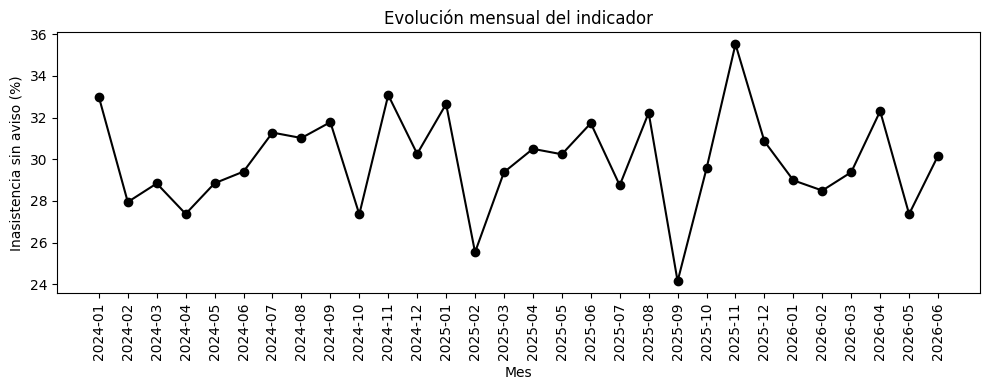

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(volumen_mes.index.astype(str), volumen_mes["tasa"],
 marker="o", color="black")
ax.set_xlabel("Mes"); ax.set_ylabel("Inasistencia sin aviso (%)")
ax.set_title("Evolución mensual del indicador")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()


In [29]:
estratos = (citas_trab.groupby(["sede_norm", "especialidad_norm"]).agg(citas=("inasistencia", "size"),inasistencias=("inasistencia", "sum")))
print("Total de combinaciones sede x especialidad:", len(estratos))
print("Estratos con menos de 30 citas :", (estratos["citas"] < 30).sum())
print("Estratos con menos de 10 inasistencias :", (estratos["inasistencias"] <10).sum())
display(estratos.sort_values("citas").head(10))

Total de combinaciones sede x especialidad: 150
Estratos con menos de 30 citas : 10
Estratos con menos de 10 inasistencias : 10


citas  inasistencias
sede_norm      especialidad_norm                      
cap carabayllo neurologia             4              2
               ginecologia            4              0
               cardiologia            7              1
               oftalmologia           7              2
               dermatologia           9              1
               odontologia           10              3
               endocrinologia        10              3
               pediatria             11              5
               medicina general      12              2
               traumatologia         15              6

**Preguntas a responder en el notebook (Paso 12)**

**12.1 ¿Cuántos meses de historia hay y considera que son suficientes? Justifique en función del horizonte de predicción y de la posible estacionalidad.**

Hay 30 meses de historia, desde enero de 2024 hasta junio de 2026. Es suficiente para observar variaciones, observable hasta un 30% de variación, aunque sería recomendable seguir incorporando datos al reentrenar

**12.2 Observando la serie mensual, ¿el indicador es estable o muestra tendencia? ¿Qué implicancia tiene su respuesta para la política de reentrenamiento del modelo?**

La serie mensual no muestra una tendencia clara, sino fluctuaciones alrededor del 30 %. Por ello, recomendaría un reentrenamiento periódico, revisando el indicador mensualmente para detectar cambios.

**12.3 ¿Cuántos estratos tienen menos de treinta citas? ¿Recomendaría un modelo por estrato o un modelo único con la sede y la especialidad como variables? Argumente.**

Hay 10 estratos con menos de 30 citas. Recomendaría un modelo único, usando sede_norm y especialidad_norm como variables, porque algunos estratos tienen muy pocos registros y no permitirían entrenar un modelo independiente con suficiente confianza


# Paso 13 · Ficha de factibilidad

| Criterio de factibilidad                     | Evidencia encontrada (cifras concretas)                                                                                                                                                | Semáforo     |
| -------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------ |
| **Confiabilidad de la variable objetivo**    | 3 592 citas no atendidas; **55 registros contradictorios** entre estado y fecha de cancelación.                                                                                        | 🟠      |
| **Existencia de una línea base medible**     | Línea base real: **29,93 %**, frente al **27,00 %** ; diferencia de **2,93 puntos**.                                                                             | 🟢      |
| **Completitud de las variables clave**       | `fecha_cancelacion`: **88,88 %** faltantes; `motivo_no_asistencia`: **70,34 %**; `telefono_confirmado`: **62,53 %**.                                                                   | 🟠      |
| **Validez y consistencia de los datos**      | **79 valores fuera de dominio** y **241 registros (2,01 %)** con anticipación inconsistente con las fechas.                                                                            | 🟠      |
| **Integrabilidad entre fuentes**             | **91 citas (0,76 %)** corresponden a una sede que no existe en el catálogo.                                                                                                            | 🟠      |
| **Variables disponibles tras excluir fugas** | Se identificaron variables que no están disponibles 48 h antes, como `duracion_atencion_min`, `hora_registro_atencion`, `motivo_no_asistencia` y `fecha_cancelacion`; deben excluirse. | 🟠      |
| **Suficiencia del histórico**                | **30 meses** de datos; **10 de 150 estratos** tienen menos de 30 citas.                                                                                                                | 🟢      |
| **Cumplimiento normativo y ético**           | `diagnostico_cie10` es dato sensible de salud y fue excluido; seudonimización de **10 629 pacientes**.                                                                                 | 🟢      |
| **VEREDICTO GLOBAL**                         | El caso es viable, pero requiere corregir inconsistencias, conciliar las fuentes y asegurar que solo se utilice información disponible 48 h antes.                                     | 🟠  |


**RECOMENDACIÓN:**

Recomiendo avanzar con el Caso A de manera controlada. Actualmente existe 30 meses de información y una tasa real de inasistencia de 29,93 %. Sin embargo, antes de desarrollar un modelo es necesitamos corregir las diferencias en la información de las citas, porque 55 registros presentan contradicciones en su resultado, 79 contienen valores imposibles y 91 citas corresponden a una sede que no figura. También debemos asegurarnos de que el sistema solo utilice información que realmente esté disponible 48 horas antes de la cita. Una vez saneados estos puntos y conciliadas ambas fuentes, recomendaría continuar con el desarrollo y comparar el modelo contra una estrategia simple de llamadas para comprobar que la inversión genere un beneficio real.


# ACTIVIDAD PROPUESTA



### TAREA 1. Reformulación del Caso C

- **Sujeto de análisis:** combinación sede–especialidad–semana.
- **Variable objetivo:** número de citas programadas por sede y especialidad en cada semana.
- **Definición operativa:** conteo de citas programadas para cada combinación de sede, especialidad y semana.
- **Horizonte temporal:** próximas cuatro semanas.
- **Población y alcance:** citas ambulatorias de las sedes y especialidades de la red.
- **Decisión asociada:** redistribuir las horas médico contratadas entre sedes con anticipación mensual.
- **Restricciones:** las horas médico solo pueden redistribuirse entre sedes ubicadas en distritos contiguos y con un mes de anticipación.

### Tarea 2 · Cambiar la granularidad

In [30]:
# Semana calendario de cada cita (lunes como inicio de semana)
citas_trab["semana"] = citas_trab["fecha_cita_dt"].dt.to_period("W-SUN")

# Agregación a la granularidad del Caso C
demanda = (citas_trab
    .groupby(["sede_norm", "especialidad_norm", "semana"])
    .agg(citas_programadas=("inasistencia", "size"))
    .reset_index())

print("Filas a la nueva granularidad:", len(demanda))
print("Series distintas (sede x especialidad):",
      demanda.groupby(["sede_norm", "especialidad_norm"]).ngroups)
display(demanda.head())

Filas a la nueva granularidad: 8740
Series distintas (sede x especialidad): 150


,sede_norm,especialidad_norm,semana,citas_programadas
0,cap ate,cardiologia,2024-01-01/2024-01-07,1
1,cap ate,cardiologia,2024-01-08/2024-01-14,3
2,cap ate,cardiologia,2024-02-05/2024-02-11,2
3,cap ate,cardiologia,2024-02-19/2024-02-25,1
4,cap ate,cardiologia,2024-02-26/2024-03-03,1


Se cambió la granularidad del conjunto de datos, pasando de una fila por cita a una fila por combinación de sede, especialidad y semana. Como resultado se obtuvieron 8 740 filas, correspondientes a 150 series distintas de sede–especialidad

### TAREA 3. Evaluar suficiencia del histórico

In [31]:
semanas_por_serie = (
    demanda.groupby(["sede_norm", "especialidad_norm"])["semana"]
    .nunique()
)

print("Total de series:", len(semanas_por_serie))
print("Series con menos de 26 observaciones:",
      (semanas_por_serie < 26).sum())

Total de series: 150
Series con menos de 26 observaciones: 10


In [32]:
semanas_totales = citas_trab["semana"].nunique()

print("Semanas totales del periodo:", semanas_totales)

Semanas totales del periodo: 131


In [33]:
print("Series con semanas sin ninguna cita:",
      (semanas_por_serie < semanas_totales).sum())

Series con semanas sin ninguna cita: 150


El histórico cubre 131 semanas y existen 150 series de sede–especialidad. De las 150 series, 10 tienen menos de 26 observaciones. Además, todas las series presentan semanas sin citas

### TAREA 4. Auditoría de fugas

**estado_cita_norm** constituye una fuga porque es el resultado final de la cita y solo se conoce después de que ocurre.

**inasistencia** también constituye una fuga porque representa un resultado posterior de la cita

Estas variables deben excluirse del conjunto utilizado para generar el pronóstico futuro.

### TAREA 5. Comparar Caso A y Caso C


| Caso | Puntaje de valor | Puntaje de factibilidad | Cuadrante | Decisión recomendada |
|---|---:|---:|---|---|
| Caso A | 5 | 3 | Alto valor / Media factibilidad | Ejecutar primero |
| Caso C | 4 | 3 | Alto valor / Media factibilidad | Ejecutar después |

### Recomendación final

Recomendaría ejecutar primero el Caso A porque tiene un impacto directo sobre la reducción de inasistencias y ya cuenta con una línea base de 29,93 % para medir resultados. En cambio, el Caso C sería la segunda prioridad, debido a que requiere trabajar con una granularidad semanal y presenta series con pocas observaciones y semanas sin citas.